<a href="https://colab.research.google.com/github/FarahBelghith2/PFE/blob/main/Nettoyage_donn%C3%A9es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Partie 1 : Préparation et nettoyage des données

In [4]:

import pandas as pd
import numpy as np


In [ ]:

df = pd.read_csv("projet.csv", sep=";", encoding="latin1")
df.head()


,id,date,saison,annee,mois,heure,ferié,jour_semaine,jour_ ouvrable,meteo,temperature,humidite,vent,utilisateurs occasionnels,utilisateurs inscrits,reservations,demande_elevee
0,1,01/01/2011,1,0,1,0,0,6,0,1,0.24,0.81,0.0,3,13,16,0
1,2,01/01/2011,1,0,1,1,0,6,0,1,0.22,0.80,0.0,8,32,40,1
2,3,01/01/2011,1,0,1,2,0,6,0,1,0.22,0.80,0.0,5,27,32,1
3,4,01/01/2011,1,0,1,3,0,6,0,1,0.24,0.75,0.0,3,10,13,0
4,5,01/01/2011,1,0,1,4,0,6,0,1,0.24,0.75,0.0,0,1,1,0


In [ ]:
print(df.columns.tolist())

['id', 'date ', 'saison', 'annee', 'mois', 'heure', 'ferié', 'jour_semaine', 'jour_ ouvrable', 'meteo', 'temperature', 'humidite', 'vent', 'utilisateurs occasionnels', 'utilisateurs inscrits', 'reservations', 'demande_elevee']


In [ ]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("[^0-9a-zA-Z_]", "", regex=True)
)

print(df.columns.tolist())

['id', 'date', 'saison', 'annee', 'mois', 'heure', 'feri', 'jour_semaine', 'jour__ouvrable', 'meteo', 'temperature', 'humidite', 'vent', 'utilisateurs_occasionnels', 'utilisateurs_inscrits', 'reservations', 'demande_elevee']


In [ ]:
df = df.rename(columns={"jour__ouvrable": "jour_ouvrable"})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         17379 non-null  int64  
 1   date                       17379 non-null  object 
 2   saison                     17379 non-null  int64  
 3   annee                      17379 non-null  int64  
 4   mois                       17379 non-null  int64  
 5   heure                      17379 non-null  int64  
 6   feri                       17379 non-null  int64  
 7   jour_semaine               17379 non-null  int64  
 8   jour_ouvrable              17379 non-null  int64  
 9   meteo                      17379 non-null  int64  
 10  temperature                17379 non-null  float64
 11  humidite                   17379 non-null  float64
 12  vent                       17379 non-null  float64
 13  utilisateurs_occasionnels  17379 non-null  int

In [ ]:
df = df.rename(columns={"feri": "ferie"})

In [ ]:
print(df.columns.tolist())

['id', 'date', 'saison', 'annee', 'mois', 'heure', 'ferie', 'jour_semaine', 'jour_ouvrable', 'meteo', 'temperature', 'humidite', 'vent', 'utilisateurs_occasionnels', 'utilisateurs_inscrits', 'reservations', 'demande_elevee']


In [ ]:
df["is_special_event"] = 0

In [ ]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
df["date_iso"] = df["date"].dt.strftime("%Y-%m-%d")

In [ ]:
dates_evenements = ["2011-01-17", "2011-02-21"]

df.loc[df["date"].isin(dates_evenements), "is_special_event"] = 1


/tmp/ipykernel_474/1005888838.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df.loc[df["date"].isin(dates_evenements), "is_special_event"] = 1


In [ ]:
df.isna().sum()

,0
date,0
saison,0
heure,0
jour_semaine,0
ferie,0
jour_ouvrable,0
meteo,0
temperature,0
humidite,0
vent,0


In [ ]:
df.head()
print(df.columns.tolist())

['date', 'saison', 'heure', 'jour_semaine', 'ferie', 'jour_ouvrable', 'meteo', 'temperature', 'humidite', 'vent', 'reservations', 'is_special_event']


In [ ]:
X = df[[
    "heure",
    "jour_semaine",
    "ferie",
    "jour_ouvrable",
    "meteo",
    "temperature",
    "humidite",
    "vent",
    "is_special_event"
]]

y = df["reservations"]

In [ ]:
print(X.head())
print(y.head())
print(X.shape, y.shape)

   heure  jour_semaine  ferie  jour_ouvrable  meteo  temperature  humidite  \
0      0             6      0              0      1         0.24      0.81   
1      1             6      0              0      1         0.22      0.80   
2      2             6      0              0      1         0.22      0.80   
3      3             6      0              0      1         0.24      0.75   
4      4             6      0              0      1         0.24      0.75   

   vent  is_special_event  
0   0.0                 0  
1   0.0                 0  
2   0.0                 0  
3   0.0                 0  
4   0.0                 0  
0    16
1    40
2    32
3    13
4     1
Name: reservations, dtype: int64
(17379, 9) (17379,)


# Partie 2 : Chargement de la base propre


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import files
uploaded = files.upload()

Saving base_propre.csv to base_propre.csv


In [5]:
df = pd.read_csv("base_propre.csv")

In [6]:


df = pd.read_csv("base_propre.csv", sep=";")
df.head()

,date,saison,heure,jour_semaine,ferie,jour_ouvrable,meteo,temperature,humidite,vent,reservations,is_special_event
0,01/01/2011,1,0,6,0,0,1,0.24,0.81,0.0,16,0
1,01/01/2011,1,1,6,0,0,1,0.22,0.80,0.0,40,0
2,01/01/2011,1,2,6,0,0,1,0.22,0.80,0.0,32,0
3,01/01/2011,1,3,6,0,0,1,0.24,0.75,0.0,13,0
4,01/01/2011,1,4,6,0,0,1,0.24,0.75,0.0,1,0


In [7]:
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y", errors="coerce")
df["date"] = df["date"].dt.strftime("%d-%m-%Y")

print(df["date"].head())

0    01-01-2011
1    01-01-2011
2    01-01-2011
3    01-01-2011
4    01-01-2011
Name: date, dtype: object


In [8]:
df.head()

,date,saison,heure,jour_semaine,ferie,jour_ouvrable,meteo,temperature,humidite,vent,reservations,is_special_event
0,01-01-2011,1,0,6,0,0,1,0.24,0.81,0.0,16,0
1,01-01-2011,1,1,6,0,0,1,0.22,0.80,0.0,40,0
2,01-01-2011,1,2,6,0,0,1,0.22,0.80,0.0,32,0
3,01-01-2011,1,3,6,0,0,1,0.24,0.75,0.0,13,0
4,01-01-2011,1,4,6,0,0,1,0.24,0.75,0.0,1,0


In [39]:
from google.colab import files
files.download("base_propre.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Partie 3 : Test des modèles de régression

In [14]:
df = pd.read_csv("base_propre.csv", sep=";")

In [15]:
X = df[[
    "saison",
    "heure",
    "jour_semaine",
    "ferie",
    "jour_ouvrable",
    "meteo",
    "temperature",
    "humidite",
    "vent",
    "is_special_event"
]]

y = df["reservations"]

3.1 Séparation des données en jeu d'entraînement et jeu de test

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (13903, 10)
X_test  : (3476, 10)
y_train : (13903,)
y_test  : (3476,)


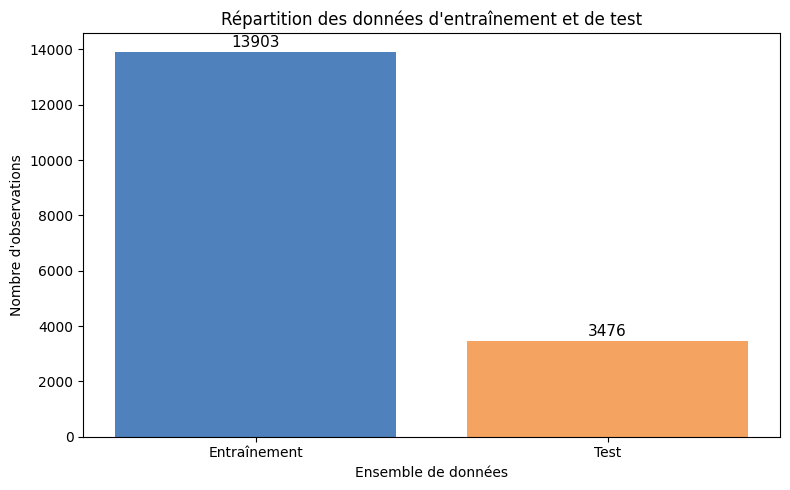

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger la base propre
df = pd.read_csv("base_propre.csv", sep=";")

# Nombre total d'observations
n = len(df)

# Répartition 80% / 20%
train = round(n * 0.8)
test = n - train

# Création du graphique
plt.figure(figsize=(8,5))
plt.bar(["Entraînement", "Test"], [train, test], color=["#4F81BD", "#F4A460"])

# Titre et axes
plt.title("Répartition des données d'entraînement et de test")
plt.xlabel("Ensemble de données")
plt.ylabel("Nombre d'observations")

# Afficher les valeurs sur les barres
for i, v in enumerate([train, test]):
    plt.text(i, v + n*0.01, str(v), ha="center", fontsize=11)

plt.tight_layout()
plt.show()

## 3.2 Ridge Regression

In [17]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

### Standardisation des données

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Entraînement du modèle Ridge

In [19]:
ridge = Ridge()
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

### Évaluation du modèle Ridge

In [20]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression")
print("MAE  :", mae_ridge)
print("RMSE :", rmse_ridge)
print("R²   :", r2_ridge)

Ridge Regression
MAE  : 106.96296285115703
RMSE : 144.1810678542561
R²   : 0.34350512277540035


## 3.3 Random Forest Regressor

In [21]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE  :", mae_rf)
print("RMSE :", rmse_rf)
print("R²   :", r2_rf)

Random Forest
MAE  : 43.64838115444682
RMSE : 67.41741719128501
R²   : 0.8564645792075677


## 3.4 Gradient Boosting Regressor

In [22]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting")
print("MAE  :", mae_gbr)
print("RMSE :", rmse_gbr)
print("R²   :", r2_gbr)

Gradient Boosting
MAE  : 56.96726869023646
RMSE : 83.24117910155788
R²   : 0.7811778339275797


## 3.5 XGBoost Regressor

In [23]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost")
print("MAE  :", mae_xgb)
print("RMSE :", rmse_xgb)
print("R²   :", r2_xgb)

XGBoost
MAE  : 43.74355697631836
RMSE : 65.52110824001682
R²   : 0.8644257187843323


### Partie 4 : Comparaison des performances

In [24]:
resultats = pd.DataFrame({
    "Modele": ["Ridge", "Random Forest", "Gradient Boosting", "XGBoost"],
    "MAE": [mae_ridge, mae_rf, mae_gbr, mae_xgb],
    "RMSE": [rmse_ridge, rmse_rf, rmse_gbr, rmse_xgb],
    "R2": [r2_ridge, r2_rf, r2_gbr, r2_xgb]
})

resultats

,Modele,MAE,RMSE,R2
0,Ridge,106.962963,144.181068,0.343505
1,Random Forest,43.648381,67.417417,0.856465
2,Gradient Boosting,56.967269,83.241179,0.781178
3,XGBoost,43.743557,65.521108,0.864426
